<a href="https://colab.research.google.com/github/carmenbonal/2526_Computacional/blob/main/codigos/ising/ISING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ISING


**Resumen**

El modelo de Ising estudia las transiciones de fase magnéticas mediante una red de espines que interactúan con sus vecinos. Utilizando el algoritmo de Metropolis, se generan configuraciones de equilibrio para calcular magnitudes como la magnetización y la energía, analizando el comportamiento del sistema frente a cambios en la temperatura.


Este trabajo ha sido realizado en colaboración por Carmen Bonal de Manuel, Pau Gomila Tarongí, Claudia González Arnaiz, Mario Hernández Cuéllar, María Dolores Navarro Ortiz y Clara Piñero García.

**1. Fundamento teórico**

**Mecánica Estadística y la Función de Partición**

El objetivo de la Mecánica Estadística es conectar las leyes microscópicas de un sistema con sus propiedades macroscópicas. Para un sistema con $N$ partículas en equilibrio termodinámico a una temperatura $T$, la probabilidad de que el sistema se encuentre en un estado $X$ está dada por la distribución de Boltzmann:

  $$P_{N}(X) = Z^{-1} e^{-\beta H_{N}(X)}$$.  
  - $\beta$: Se define como $1/(k_B T), $donde $k_B$ es la constante de Boltzmann.  
  - $H_N(X)$: Representa el Hamiltoniano o energía del sistema.  
  - $Z$: Es la función de partición, una constante de normalización que requiere integrar (o sumar) sobre todos los estados posibles del sistema.
  
   Debido a que estas integrales son extremadamente complejas de resolver analíticamente para sistemas de muchas partículas, se recurre a métodos numéricos.

   **El Método de Monte Carlo y el Algoritmo de Metropolis**
   
   Para calcular el valor esperado de un observable $\langle A \rangle$, se utiliza la ley de los grandes números, estimándolo mediante el promedio de $M$ realizaciones independientes:

  $$\langle A \rangle \approx \frac{1}{M} \sum_{i=1}^{M} A(X_i)$$
  
  ***Cadenas de Markov y Balance Detallado***

  En sistemas grandes, generar configuraciones aleatorias independientes es ineficiente porque la mayoría tienen una probabilidad casi nula. El Algoritmo de Metropolis soluciona esto generando una cadena de Markov, donde cada nuevo estado depende del anterior.  Para que el sistema converja a la distribución de equilibrio deseada, se impone la condición de balance detallado:
  $$g(X') T(X' \rightarrow X) = g(X) T(X \rightarrow X')$$
  


  En la práctica, la probabilidad de transición $T(X \rightarrow X')$ elegida es:
  
  $$T(X \rightarrow X') = \min(1, e^{-\beta[E(X') - E(X)]})$$

  **El Modelo de Ising Bi-dimensional**
  
  Este modelo simplifica el estudio de materiales que cambian de paramagnéticos a ferromagnéticos según la temperatura. Sus características fundamentales son:
  - Red y Espines: Se define en una red cuadrada de $N \times N$ nudos. En cada nudo hay un espín $s(i,j)$ que solo puede valer $1$ (up psin) o $-1$ (down spin).  
  

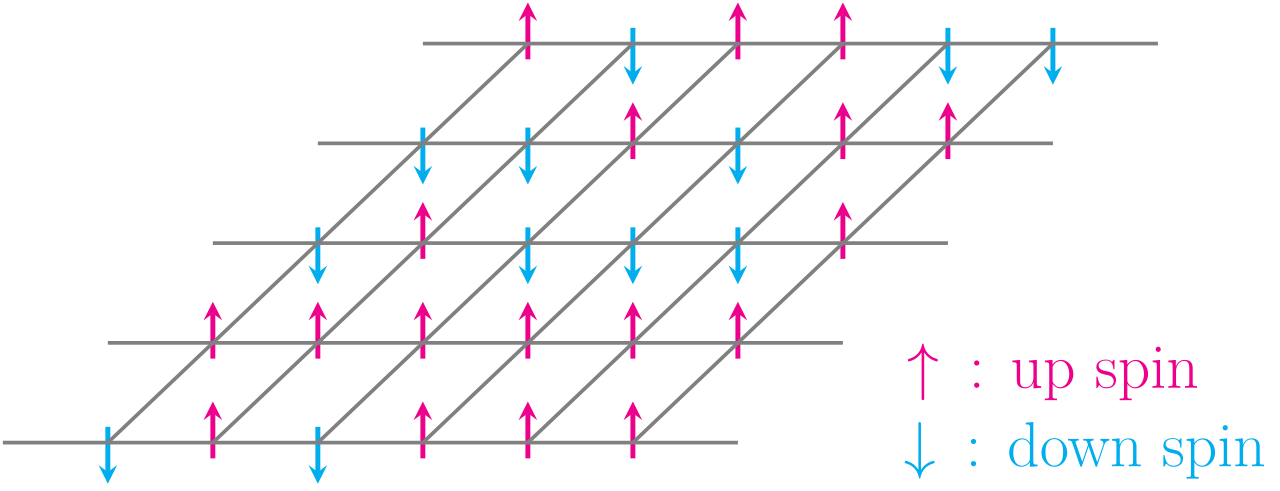


  - Energía del Sistema: La interacción se da entre vecinos próximos y se rige por el Hamiltoniano:$$E(S) = -\frac{1}{2} \sum_{i=1}^{N} \sum_{j=1}^{N} s(i,j) [s(i,j+1) + s(i,j-1) + s(i+1,j) + s(i-1,j)]$$.  
  
  - Condiciones de Contorno: Se utilizan condiciones periódicas para simular un sistema infinito (los bordes de la red se conectan con el lado opuesto).

  **Transición de Fase y Fenómenos Críticos**

  El Modelo de Ising es el paradigma para estudiar las transiciones de fase de segundo orden. En estos sistemas, existe una temperatura crítica, $T_c$, que separa dos estados de la materia con simetrías distintas:  
  - Fase Ordenada ($T < T_c$): A temperaturas bajas, la interacción energética entre espines vecinos predomina sobre la agitación térmica. El sistema tiende a minimizar su energía alineando los espines en una misma dirección, lo que genera una magnetización espontánea no nula ($m \neq 0$).  
  - Fase Desordenada ($T > T_c$): A temperaturas altas, el desorden térmico (entropía) domina el sistema. Las orientaciones de los espines se vuelven aleatorias y la magnetización promedio decae a cero ($m \approx 0$), comportándose como un material paramagnético.


  **Caracterización del Punto Crítico y Exponentes**

  En las proximidades de $T_c$, el sistema experimenta fluctuaciones extremas que se manifiestan en el comportamiento de diversas magnitudes termodinámicas:  
  - Calor Específico ($c_N$): Esta magnitud mide la respuesta del sistema ante cambios de temperatura. En el punto crítico, el calor específico presenta un máximo pronunciado (que divergiría en un sistema infinito), lo que permite localizar numéricamente el valor de $T_c$ mediante simulaciones.  
  - Longitud de Correlación: Representa la distancia a la cual un espín todavía "influye" en el estado de otro. Cerca de $T_c$, esta distancia aumenta drásticamente, indicando que el sistema se vuelve "cooperativo" a escalas globales antes de cambiar de fase.  
  - Efectos de Tamaño Finito: Dado que las simulaciones se realizan en redes de tamaño $N$ finito, las divergencias teóricas (como las predichas por Onsager) se ven suavizadas y desplazadas. El análisis de cómo cambian estos máximos según el valor de $N$ permite extrapolar el comportamiento del sistema en el límite termodinámico ($N \rightarrow \infty$).

**2. Metodología y herramientas**

La implementación de este simulador se ha realizado mediante una colaboración con el modelo de lenguaje Gemini (IA), que ha actuado como una herramienta de apoyo para el desarrollo de un motor de simulación de Física Estadística en Python. A través de este proceso, la IA facilitó la integración del algoritmo de Metropolis para garantizar que el sistema evolucione hacia la distribución de equilibrio de Boltzmann y el manejo preciso de las interacciones entre espines en una red bidimensional. Además de optimizar el cálculo de la diferencia de energía ($\Delta E$) y el cumplimiento de las condiciones de contorno periódicas, Gemini asistió en la estructuración de un fichero de datos compatible con el script 'animacion_ising.py', permitiendo transformar las ecuaciones de interacción magnética en una animación dinámica mediante la librería matplotlib.

 **2.1 Prompt de Diseño**

Para asegurar la obtención de un código funcional y riguroso que resuelva el problema de Ising, se establecieron las siguientes especificaciones:

*Objetivo:* Implementación del algoritmo de Metropolis:Inicialización del sistema:

 Se elige un punto al azar $(n, m)$ de la red de tamaño $N \times N$ en cada intento de cambio. Evaluamos el cambio de energía: $$\Delta E = 2s(n,m) \sum_{vecinos} s_{vecino}$$

 *Criterio de aceptación:* Generación de un número aleatorio uniforme $\xi \in [0,1]$ para decidir el cambio de signo del espín según la probabilidad $p = \min(1, e^{-\beta \Delta E})$, asegurando la convergencia.


 *Entorno y librerías:* Uso de NumPy para la gestión eficiente del retículo de espines y el cálculo matricial. Generación de un fichero de salida estructurado por bloques para su visualización con el script de animación proporcionado.

 **2.2 Prompt de Magnetización frente a temperatura**

Para el calculo y grafica de la Magnetización frenta a la temperatura usando numba, se ha utilizado Claude.

Se va a analizar el uso de modelos de IA como orquestadores dentro del flujo de trabajo en Física Computacional, comparando su funcionamiento con herramientas clásicas del stack HPC.

A nivel conceptual, el modelo actúa como un **orquestador semántico**, capaz de interpretar el problema físico y decidir dinámicamente qué herramientas computacionales emplear. Esto permite abstraer la complejidad del desarrollo, acercando el enfoque a paradigmas de programación simbólica como LISP.

En la capa de ejecución, la IA facilita la generación de código optimizado, especialmente en entornos como Python con Numba, donde puede anticipar la paralelización y la vectorización necesarias para simulaciones eficientes.

Finalmente, a nivel de hardware, el modelo puede servir como puente entre la formulación matemática y arquitecturas de alto rendimiento, incluyendo GPU o incluso implementaciones en FPGA, actuando como un traductor entre distintos niveles del stack computacional.

En conjunto, este enfoque no sustituye las herramientas HPC tradicionales, sino que introduce una capa de **metaprogramación inteligente** que mejora la eficiencia y reduce la complejidad del desarrollo.

 [Ver informe completo](https://colab.research.google.com/drive/192HKWUCqKTBGbHcK8P42Wh7I3wLzCqYw#scrollTo=YmKrCFfx5xBu)

**Resultados y discusión**

**1. Posiblemes régimen a distintas temperaturas**

Usando el código explicado para el mismo tamaño de red (N=32) se estudiaron los tres posibles régimen del sistema:

1.	Baja Temperatura (T=1.5) (Fase Ferromagnética)
2.	Temperatura crítica (T=2.269) (Temperatura Crítica - Tc)
3.	Alta Temperatura (T=4.0) (Fase Paramagnética)

Comentario: a contiuación, se muestra un código, que une los dos explicados anteriormente, para mostrar los resultados obtenidos a las tres temperaturas distintas mencionadas.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# ================================================================================
# 1. PARÁMETROS DE LA SIMULACIÓN
# ================================================================================
N = 32                  # Tamaño del retículo (N x N)
PASOS_MC = 400          # Pasos Monte Carlo totales
FRECUENCIA_GUARDADO = 5 # Guardar configuración cada X pasos
TEMPERATURAS = [1.5, 2.269, 4.0] # [Baja, Crítica, Alta]
INTERVALO = 50          # Velocidad de la animación (ms)

# ================================================================================
# 2. FUNCIONES LÓGICAS (MODELO DE ISING)
# ================================================================================
def inicializar_sistema(n):
    """Crea una configuración inicial aleatoria de espines."""
    return np.random.choice([-1, 1], size=(n, n))

def paso_metropolis(grid, n, temp):
    """Realiza un paso Monte Carlo completo (N^2 intentos)."""
    for _ in range(n**2):
        i, j = np.random.randint(0, n, size=2)
        s = grid[i, j]
        # Condiciones de contorno periódicas
        vecinos = (grid[(i + 1) % n, j] + grid[(i - 1) % n, j] +
                   grid[i, (j + 1) % n] + grid[i, (j - 1) % n])
        de = 2 * s * vecinos

        if de <= 0 or np.random.rand() < np.exp(-de / temp):
            grid[i, j] *= -1
    return grid

# ================================================================================
# 3. EJECUCIÓN DE LAS SIMULACIONES
# ================================================================================
print("Ejecutando simulaciones... Por favor, espera.")
datos_por_temperatura = []

for T in TEMPERATURAS:
    grid = inicializar_sistema(N)
    fotogramas = []
    for paso in range(PASOS_MC):
        grid = paso_metropolis(grid, N, T)
        if paso % FRECUENCIA_GUARDADO == 0:
            fotogramas.append(grid.copy())
    datos_por_temperatura.append(fotogramas)
    print(f"Simulación para T={T} completada.")

# ================================================================================
# 4. CREACIÓN DE LA ANIMACIÓN TRIPLE
# ================================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f"Simulación Modelo de Ising (N={N})", fontsize=16)

ims = []
for i, ax in enumerate(axes):
    ax.axis("off")
    ax.set_title(f"Temperatura T = {TEMPERATURAS[i]}")
    # Inicializamos la visualización con el primer frame de cada simulación
    im = ax.imshow(datos_por_temperatura[i][0], cmap="binary", vmin=-1, vmax=1)
    ims.append(im)

def update(frame_idx):
    """Actualiza los tres gráficos a la vez en cada frame."""
    for i, im in enumerate(ims):
        im.set_data(datos_por_temperatura[i][frame_idx])
    return ims

# Crear la animación
n_frames = len(datos_por_temperatura[0])
anim = FuncAnimation(fig, update, frames=n_frames, interval=INTERVALO, blit=True)

# Cerrar el plot estático para que no aparezca duplicado
plt.close()

# Mostrar el resultado final en el Notebook
HTML(anim.to_jshtml())


Ejecutando simulaciones... Por favor, espera.
Simulación para T=1.5 completada.
Simulación para T=2.269 completada.
Simulación para T=4.0 completada.


Al observar las tres simulaciones en paralelo, podemos identificar claramente el comportamiento del sistema según la termodinámica estadística:

1.	**Fase Ferromagnética (T<Tc):** A bajas temperaturas (como T=1.5), se observa que la red está prácticamente dominada por un solo color (blanco o negro), con apenas unos pocos píxeles aislados del color opuesto.
Esto se debe a que, a esta escala, la energía térmica es insuficiente para vencer la energía de interacción entre vecinos. El sistema minimiza su energía total alineando los espines en una misma dirección, logrando una magnetización espontánea alta. Esto confirma que el sistema se encuentra en su fase ordenada o ferromagnética.

2.	**Punto Crítico y Fluctuaciones (T≈Tc):** Para la temperatura crítica, se observan grandes cúmulos (clusters) de ambos colores que fluctúan constantemente. Estas formas no son cuadradas ni homogéneas, sino que presentan un aspecto fractal. La temperatura T=2.27 está extremadamente cerca del valor exacto calculado por Lars Onsager (Tc≈2.269).
En este punto crítico, la tendencia al orden (alineamiento por interacción) y al desorden (ruido térmico) están perfectamente equilibradas. Las fluctuaciones ocurren a todas las escalas espaciales, lo que significa que un solo cambio de espín puede desencadenar una reacción en cadena en bloques de cualquier tamaño.

3.	**Fase Paramagnética (T>Tc):** A altas temperaturas (como T=4.0), el sistema muestra una mezcla caótica, homogénea y muy "granulada" de píxeles blancos y negros.
Para esta temperatura, el desorden inducido por la entropía supera por completo a las fuerzas de alineamiento magnético. La agitación térmica es tan violenta que voltea los espines constantemente, impidiendo la formación de dominios estables. La magnetización neta promedio del sistema tiende a cero (⟨M⟩≈0), lo que define la fase paramagnética o desordenada.


**2. Cálculo de la magnetización promedio en función de la temperatura y temperatura crítica.**

## 2. Cálculo de la magnetización promedio en función de la temperatura y temperatura crítica

EL objetivo ahora es estimar el valor esperado de la magnetización por espín, ⟨|M|⟩, en función de la temperatura T para el modelo de Ising 2D en una red de 32×32 con condiciones de contorno periódicas. La dinámica se implementa mediante el algoritmo de **Metropolis**: en cada paso Monte Carlo se realizan N² intentos de inversión de espín, aceptándose siempre los que disminuyen la energía y aceptándose con probabilidad exp(−ΔE/T) los que la aumentan. Partiendo de una configuración ordenada (s(i,j) = +1), se deja evolucionar el sistema 10⁶ pasos por cada temperatura, recorriendo un rango entre T = 1.0 y T = 4.0 con un muestreo más denso cerca de la temperatura crítica Tc ≈ 2.269 J/kB.

Como ⟨|M|⟩ es un promedio térmico y no el valor instantáneo de una única configuración, la simulación se divide en dos fases: una primera fase de **termalización** (10 000 pasos) durante la cual el sistema relaja desde la configuración inicial pero **no se mide**, y una segunda fase de **medida** (990 000 pasos) en la que se acumula |M| cada 10 pasos para obtener una estimación promediada sobre el ensemble. Este espaciamiento entre medidas reduce la correlación temporal entre muestras, especialmente notable cerca de Tc por el fenómeno de *critical slowing down*.

La principal optimización aplicada al código es el uso de **Numba**, un compilador JIT (*just-in-time*) para Python que traduce las funciones decoradas con `@njit` a código máquina nativo. Como el bucle de Metropolis ejecuta del orden de N² × 10⁶ ≈ 10⁹ operaciones por temperatura, una implementación en Python puro resultaría inviable (varias horas por punto de temperatura). Con Numba la velocidad aumenta aproximadamente en dos órdenes de magnitud, lo que permite completar el barrido completo de temperaturas en pocos minutos sin sacrificar el tamaño de la red ni el número de pasos exigidos en el enunciado.

El resultado de la estimación de ⟨|M|⟩ en función de la temperatura se muestra en la siguiente imagen:

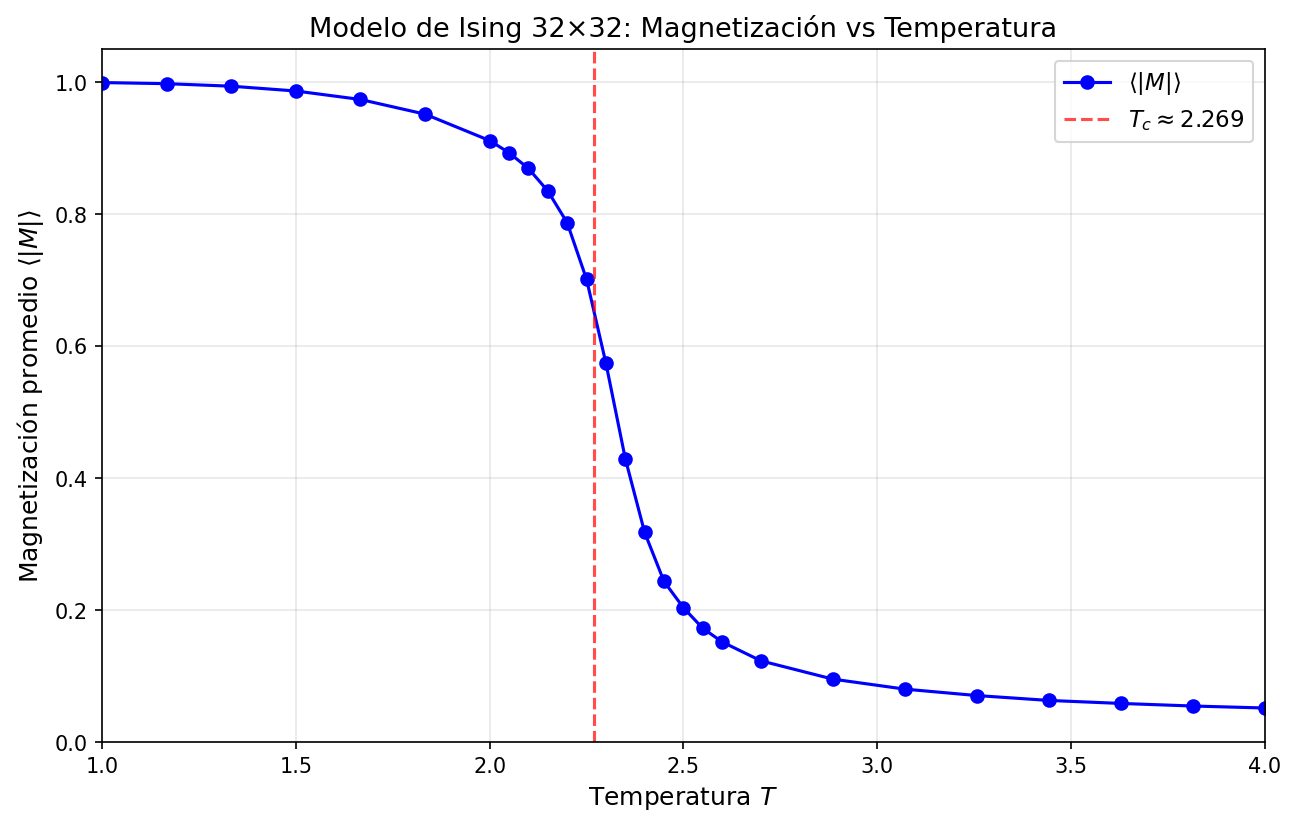


A partir de los resultados presentados en la gráfica, se pueden sintetizar las siguientes conclusiones sobre el comportamiento del sistema:

*   **Transición de Fase:** Se observa claramente el paso de una **fase ordenada (ferromagnética)**, donde $\langle |M| \rangle \approx 1$ para $T < T_c$, hacia una **fase desordenada (paramagnética)** para $T > T_c$, donde la agitación térmica anula la magnetización neta.
*   **Punto Crítico ($T_c \approx 2.269K$):** La caída abrupta de la curva identifica la temperatura crítica de Onsager. Es en esta región donde las fluctuaciones de espín alcanzan todas las escalas espaciales, rompiendo el orden de largo alcance.
*   **Efectos de Tamaño Finito y Suavidad:** La transición no se presenta como un salto infinitamente brusco, sino como una curva progresiva. Esta **suavidad** es característica de sistemas finitos (red de $32 \times 32$), donde las dimensiones físicas limitan las divergencias matemáticas. Además, la ausencia de ruido en los puntos sugiere que el sistema alcanzó un excelente equilibrio termodinámico mediante un número suficiente de pasos de Monte Carlo.

### Implementación y Detalles de Cómputo

El código que se presenta a continuación constituye el núcleo algorítmico de la simulación. Debido a la alta demanda de recursos computacionales necesaria para generar resultados con este nivel de precisión y suavidad estadística, el procesamiento principal se realizó de forma externa en un **entorno de desarrollo local (VSCode)**.

Esta metodología permitió aprovechar la potencia de cálculo de una máquina local para ejecutar el barrido de temperaturas completo, evitando las limitaciones de tiempo de ejecución de la nube. Por lo tanto, el bloque de código se incluye en este documento con un carácter puramente **informativo y de revisión**, permitiendo consultar la lógica del algoritmo de Metrópolis sin necesidad de replicar el costoso proceso de computación en tiempo real.

In [ ]:
"""
Modelo de Ising 2D - Magnetización en función de la temperatura.

Configuración inicial ordenada (s(i,j) = +1).
Termaliza el sistema y luego promedia |M| sobre muchas configuraciones
para estimar el valor esperado <|M|>.
"""
import numpy as np
import matplotlib.pyplot as plt
from numba import njit
import time

# --- Parámetros de la simulación ---
# Total = PASOS_TERMALIZACION + PASOS_MEDIDA = 10^6 pasos MC por temperatura,
# tal y como pide el enunciado.
N = 32                          # Tamaño del retículo (N x N)
PASOS_TERMALIZACION =  10_000   # pasos MC para termalizar (sin medir)
PASOS_MEDIDA        = 990_000   # pasos MC durante los que se acumulan medidas
INTERVALO_MUESTRA   = 10        # se mide |M| cada estos pasos (reduce correlación)
FICHERO_SALIDA = "magnetizacion_vs_temperatura.dat"


@njit(cache=True)
def paso_metropolis(grid, n, temp):
    """Un paso Monte Carlo = N*N intentos de flip (un 'sweep')."""
    for _ in range(n * n):
        i = np.random.randint(0, n)
        j = np.random.randint(0, n)
        s = grid[i, j]
        vecinos = (grid[(i + 1) % n, j] + grid[(i - 1) % n, j]
                 + grid[i, (j + 1) % n] + grid[i, (j - 1) % n])
        de = 2 * s * vecinos
        if de <= 0 or np.random.random() < np.exp(-de / temp):
            grid[i, j] = -s


@njit(cache=True)
def magnetizacion_absoluta(grid, n):
    """|M| por espín de la configuración actual."""
    s = 0
    for i in range(n):
        for j in range(n):
            s += grid[i, j]
    return abs(s) / (n * n)


@njit(cache=True)
def simular_a_temperatura(T, n, pasos_term, pasos_med, intervalo):
    """
    Devuelve <|M|> a temperatura T.
    Configuración inicial ordenada (todos +1).
    """
    grid = np.ones((n, n), dtype=np.int64)

    # Termalización (sin medir)
    for _ in range(pasos_term):
        paso_metropolis(grid, n, T)

    # Acumulación de medidas
    suma_m = 0.0
    n_muestras = 0
    for paso in range(pasos_med):
        paso_metropolis(grid, n, T)
        if paso % intervalo == 0:
            suma_m += magnetizacion_absoluta(grid, n)
            n_muestras += 1

    return suma_m / n_muestras


# --- Rango de temperaturas ---
# Densificamos puntos cerca de Tc ≈ 2.269 para resolver bien la transición.
T_baja  = np.linspace(1.0, 2.0, 6,  endpoint=False)   # fase ordenada
T_cerca = np.linspace(2.0, 2.6, 13)                   # zona crítica (densa)
T_alta  = np.linspace(2.7, 4.0, 8)                    # fase desordenada
temperaturas = np.concatenate([T_baja, T_cerca, T_alta])

magnetizaciones = np.zeros_like(temperaturas)

print("Modelo de Ising 2D — Magnetización vs Temperatura")
print(f"N = {N}, termalización = {PASOS_TERMALIZACION}, "
      f"medida = {PASOS_MEDIDA} (cada {INTERVALO_MUESTRA})")
print("=" * 60)

# Compilación previa de Numba con un punto pequeño (no cuenta en el tiempo)
print("Compilando con Numba...")
_ = simular_a_temperatura(2.0, N, 100, 100, 10)

t_inicio = time.time()
for k, T in enumerate(temperaturas):
    t0 = time.time()
    M = simular_a_temperatura(T, N, PASOS_TERMALIZACION,
                              PASOS_MEDIDA, INTERVALO_MUESTRA)
    magnetizaciones[k] = M
    print(f"  T = {T:5.3f}   <|M|> = {M:.4f}   ({time.time() - t0:5.1f} s)")

print("=" * 60)
print(f"Tiempo total: {time.time() - t_inicio:.1f} s")

# --- Guardar datos ---
np.savetxt(FICHERO_SALIDA,
           np.column_stack((temperaturas, magnetizaciones)),
           fmt='%.4f', delimiter=',',
           header='Temperatura, <|M|>')
print(f"Datos guardados en: {FICHERO_SALIDA}")

# --- Gráfica ---
plt.figure(figsize=(10, 6))
plt.plot(temperaturas, magnetizaciones, 'o-', color='blue',
         markersize=6, label=r'$\langle |M| \rangle$')
plt.axvline(x=2.269, color='red', linestyle='--', alpha=0.7,
            label=r'$T_c \approx 2.269$')
plt.xlabel('Temperatura $T$', fontsize=12)
plt.ylabel(r'Magnetización promedio $\langle |M| \rangle$', fontsize=12)
plt.title(f'Modelo de Ising {N}×{N}: Magnetización vs Temperatura',
          fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim(temperaturas.min(), temperaturas.max())
plt.ylim(0, 1.05)
plt.savefig('magnetizacion_vs_temperatura.png', dpi=150, bbox_inches='tight')
print("Gráfica guardada como: magnetizacion_vs_temperatura.png")
plt.show()